Degenerate backtesting code. Given UPRO didn't exist pre GFC im simulating it using SPY and simply applying the leverage manually. It would be nice to get gold prices from a earlier date then 2005 but that is the limit of the gold etf. Code is otherwise functional and displays decent return with this strat. 

100%|██████████| 1/1 [00:00<00:00, 39945.75it/s]


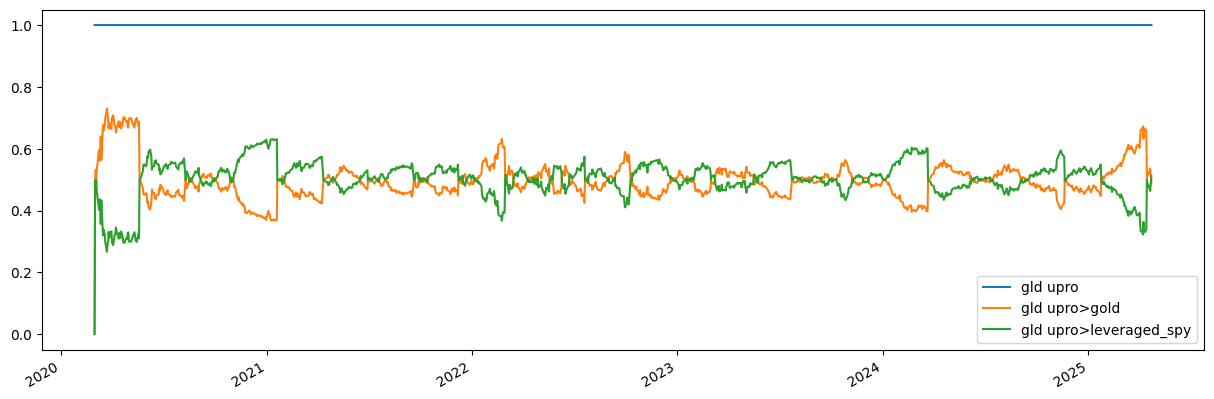

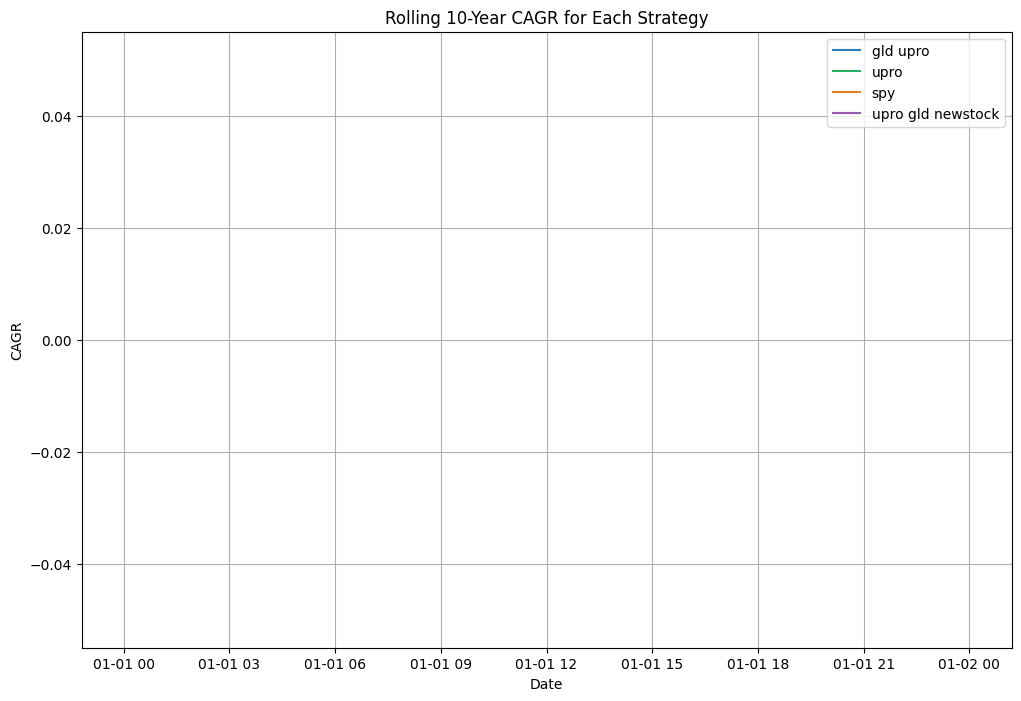

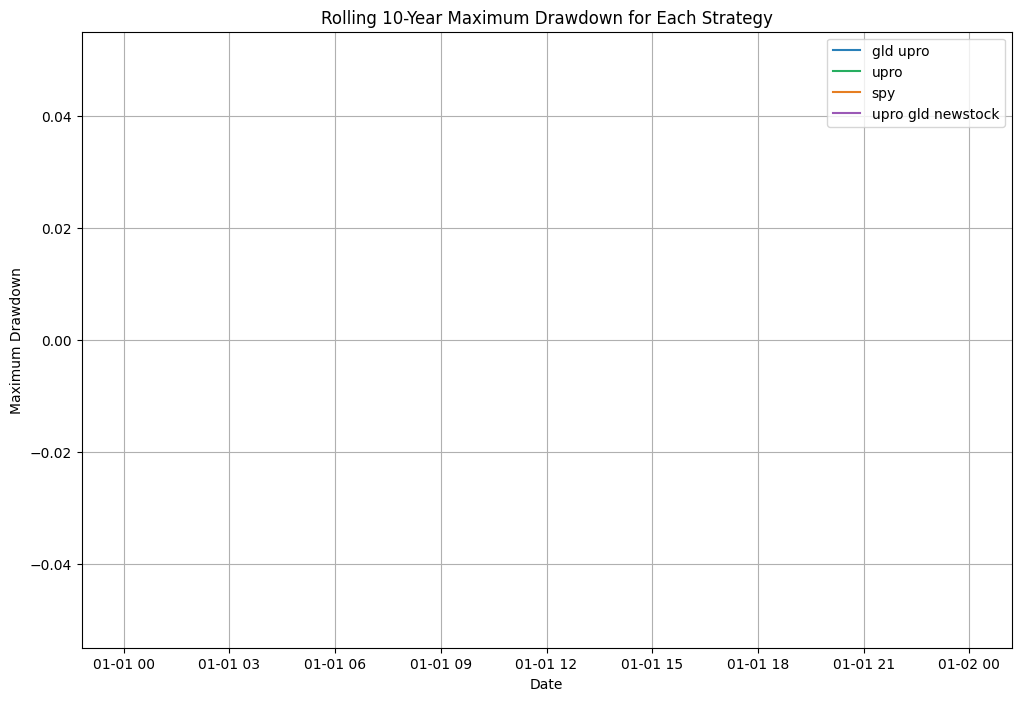

Median CAGR of each strategy:
gld upro: nan %
upro: nan %
spy: nan %
upro gld newstock: nan %


/Users/patrickwiltshire/Library/Python/3.9/lib/python/site-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/patrickwiltshire/Library/Python/3.9/lib/python/site-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/patrickwiltshire/Library/Python/3.9/lib/python/site-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/patrickwiltshire/Library/Python/3.9/lib/python/site-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


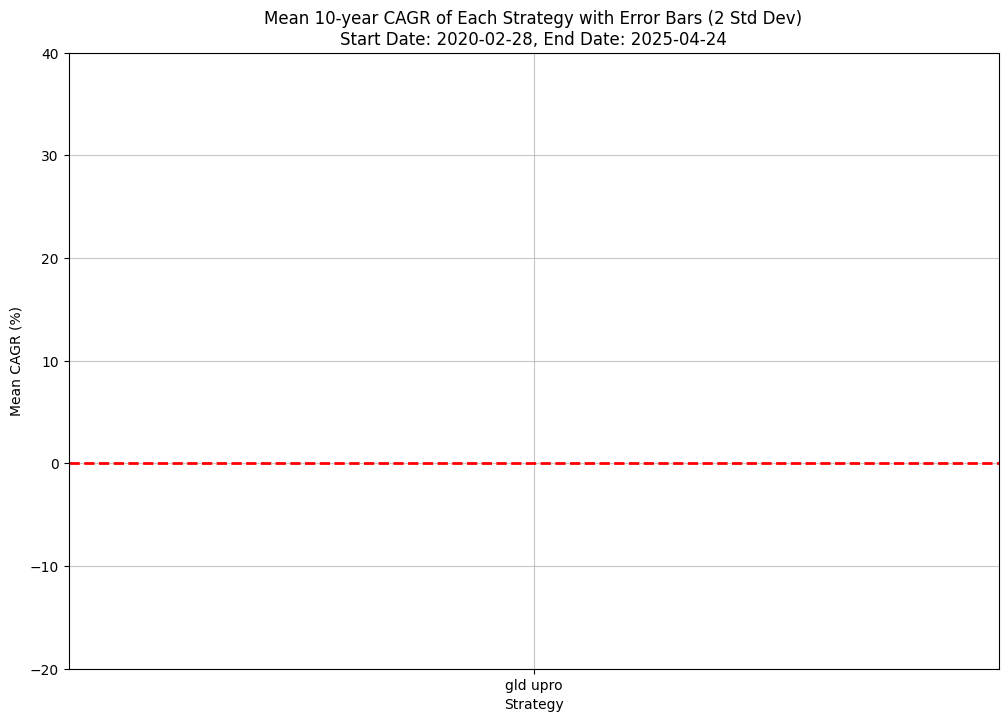

In [5]:
import bt
import pandas as pd
import matplotlib.pyplot as plt

############################################
### --- Define number of years to use --- ###
############################################
years = 10


######################################
### --- Main --- ####################
######################################
# Define the start and end dates
startDate = '2020-02-28'
endDate = '2025-04-24'


# --- Dividend and Returns Setup for S&P 500 (SPY) ---

# 1. Simulate a 1.5% annual dividend yield
annual_dividend_yield = 0.015  # 1.5% per year
daily_dividend_yield = (1 + annual_dividend_yield) ** (1 / 252) - 1  # Convert to daily yield

# 2. Simulate a 1% annual expense ratio (management fee)
annual_expense_ratio = 0.01  # 1% per year
daily_expense_ratio = (1 - annual_expense_ratio) ** (1 / 252) - 1  # Daily drag (will be negative)

# 3. Download S&P 500 price data (no dividends included)
sp500_data = bt.get('^GSPC', start=startDate, end=endDate)

# 4. Calculate daily returns (price-only)
sp500_returns = sp500_data.pct_change().dropna()

# 5. Add daily dividend yield to create total return
sp500_total_returns = sp500_returns + daily_dividend_yield

# 6. Apply 3x leverage to total return
leveraged_spy_returns = sp500_total_returns * 3

# 7. Subtract the daily expense ratio (this simulates the ongoing cost)
leveraged_spy_returns_adjusted = leveraged_spy_returns + daily_expense_ratio

# 8. Create cumulative price series for both total return and leveraged ETF
sp500_total_return_prices = (1 + sp500_total_returns).cumprod() * sp500_data.iloc[0]
leveraged_spy_prices = (1 + leveraged_spy_returns_adjusted).cumprod() * sp500_data.iloc[0]

# 9. Store for later use
spy_data = sp500_total_return_prices



# --- Gold ETF Simulation (with Management Fee) ---

# 1. Download spot gold price data
gold_data = bt.get('gold', start=startDate, end=endDate)

# 2. Calculate daily gold returns
gold_returns = gold_data.pct_change().dropna()

# 3. Simulate a 0.15% annual management fee for a gold ETF (like GLD)
annual_fee = 0.0015  # 0.15% per year
daily_fee = (1 - annual_fee) ** (1 / 252) - 1  # Approximate daily fee drag (small negative)

# 4. Apply the management fee (small negative) to the gold returns
gold_etf_returns = gold_returns #+ daily_fee

# 5. Create a cumulative price series starting at 100
synthetic_gold_etf = (1 + gold_etf_returns).cumprod() * gold_data.iloc[0]

# 6. Assign for later use
gld_data = synthetic_gold_etf


# --- New Stock Simulation (8% Annual Growth, Adjusted) ---

# 1. Adjust for drawdowns: Assume 45% drawdown impact on 8% annual growth
adjusted_annual_growth = 0.08 - 0.08 * 0.45  # Lower expected compounding
daily_growth_rate = (1 + adjusted_annual_growth) ** (1 / 252) - 1  # Convert to daily growth rate

# 2. Create a constant daily returns series for the new stock
new_stock_returns = pd.Series(daily_growth_rate, index=spy_data.index)

# 3. Generate the cumulative price series starting at the same initial price as SPY
new_stock_prices = (1 + new_stock_returns).cumprod() * 100


# --- Combine Assets for Different Strategies ---

# --- Strategy 2: Gold + Leveraged SPY (equal-weighted for example) ---
dataStrat2 = gld_data.copy()
dataStrat2['leveraged_spy'] = leveraged_spy_prices

# --- Strategy 3: Leveraged SPY Alone (benchmark) ---
dataStrat3 = leveraged_spy_prices

# --- Strategy 4: 70% UPRO + 30% GLD + 30% New Stock ---
# NOTE: Leveraged SPY returns * 0.7 weight, Gold returns * 0.3 weight, New Stock returns * 0.3 weight
# (weights can sum over 1; this models leverage or exposure stacking)
strategy4_returns = (leveraged_spy_returns * 0.4) + (gold_returns * 0.3) + (new_stock_returns * 0.3)

# Create cumulative price series for Strategy 4
strategy4_prices = (1 + strategy4_returns).cumprod() * spy_data.iloc[0]

# --- Prepare Data Structure for Strategy 4 ---
dataStrat4 = dataStrat2.copy()
dataStrat4['new_stock'] = new_stock_prices



class RebalanceQuarterly(bt.Algo):
    def __init__(self, interval=63):
        super().__init__()
        self.last_rebalance_date = None
        self.interval = interval

    def __call__(self, target):
        if target.now is None:
            return True

        if self.last_rebalance_date is None or (target.now - self.last_rebalance_date).days >= self.interval:
            self.last_rebalance_date = target.now
            return bt.algos.Rebalance()(target)

        return True




s2 = bt.Strategy('gld upro', [
    bt.algos.RunEveryNPeriods(14),     # Buy every 14 days
    bt.algos.SelectAll(),
    bt.algos.WeighEqually(),
    RebalanceQuarterly(interval=63)    # Actually rebalance every ~quarter
])

s3 = bt.Strategy('upro', [
    bt.algos.RunEveryNPeriods(14),
    bt.algos.SelectAll(),
    bt.algos.WeighEqually(),
    RebalanceQuarterly(interval=63)    # Actually rebalance every ~quarter
])

s4 = bt.Strategy('spy', [
    bt.algos.RunEveryNPeriods(14),
    bt.algos.SelectAll(),
    bt.algos.WeighEqually(),
    RebalanceQuarterly(interval=63)    # Actually rebalance every ~quarter
])

s5 = bt.Strategy('upro gld newstock', [
    bt.algos.RunEveryNPeriods(14),
    bt.algos.SelectAll(),
    bt.algos.WeighEqually(),
    RebalanceQuarterly(interval=63)    # Actually rebalance every ~quarter
])



# Create backtests
test1 = bt.Backtest(s2, dataStrat2)
test3 = bt.Backtest(s3, dataStrat3)
test4 = bt.Backtest(s4, spy_data)
test5 = bt.Backtest(s5, dataStrat4)

# Run the backtests
res = bt.run(test1, test3, test4, test5)
# Display results
resGldUpro = bt.run(test1)
# Show weightings
resGldUpro.plot_weights()

#res.display()
# Function to calculate CAGR
def calculate_cagr(series, periods_per_year=252):
    n = len(series) / periods_per_year
    return (series[-1] / series[0]) ** (1 / n) - 1

# Function to calculate CAGR using geometric mean of returns
def calculate_cagr_complex(series, periods_per_year=252):
    # Calculate daily returns
    daily_returns = series.pct_change().dropna()
    
    # Calculate the geometric mean of daily returns
    geometric_mean = (1 + daily_returns).prod() ** (1 / len(daily_returns)) - 1
    
    # Annualize the geometric mean to get the CAGR
    cagr = (1 + geometric_mean) ** periods_per_year - 1
    
    return cagr

# Function to calculate maximum drawdown
def calculate_max_drawdown(series):
    roll_max = series.cummax()
    drawdown = (series - roll_max) / roll_max
    return drawdown.min()

# Calculate rolling CAGR and MDD for each strategy
rolling_window = years * 252  
cagr_s2 = res['gld upro'].prices.rolling(window=rolling_window).apply(calculate_cagr_complex)
cagr_s3 = res['upro'].prices.rolling(window=rolling_window).apply(calculate_cagr_complex)
cagr_s4 = res['spy'].prices.rolling(window=rolling_window).apply(calculate_cagr_complex)
cagr_s5 = res['upro gld newstock'].prices.rolling(window=rolling_window).apply(calculate_cagr_complex)

mdd_s2 = res['gld upro'].prices.rolling(window=rolling_window).apply(calculate_max_drawdown)
mdd_s3 = res['upro'].prices.rolling(window=rolling_window).apply(calculate_max_drawdown)
mdd_s4 = res['spy'].prices.rolling(window=rolling_window).apply(calculate_max_drawdown)
mdd_s5 = res['upro gld newstock'].prices.rolling(window=rolling_window).apply(calculate_max_drawdown)
# Hex Colours 
gld_upro_color = '#2980B9'
upro_color = '#27AE60'
spy_color = '#E67E22'
new_stock_color = '#9B59B6'

strategy_colors = [gld_upro_color, upro_color, spy_color, new_stock_color]

# Plot the rolling 5-year CAGR for each strategy
plt.figure(figsize=(12, 8))
plt.plot(cagr_s2, label='gld upro', color=gld_upro_color)
plt.plot(cagr_s3, label='upro', color=upro_color)
plt.plot(cagr_s4, label='spy', color=spy_color)
plt.plot(cagr_s5, label='upro gld newstock', color=new_stock_color)
plt.xlabel('Date')
plt.ylabel('CAGR')
plt.title(f'Rolling {years}-Year CAGR for Each Strategy')
plt.legend()
plt.grid()
plt.show()

# Plot the rolling 5-year Maximum Drawdown for each strategy
plt.figure(figsize=(12, 8))
plt.plot(mdd_s2, label='gld upro', color=gld_upro_color)
plt.plot(mdd_s3, label='upro', color=upro_color)
plt.plot(mdd_s4, label='spy', color=spy_color)
plt.plot(mdd_s5, label='upro gld newstock', color=new_stock_color)
plt.xlabel('Date')
plt.ylabel('Maximum Drawdown')
plt.title(f'Rolling {years}-Year Maximum Drawdown for Each Strategy')
plt.legend()
plt.grid()
plt.show()

# Calculate the mean and standard deviation of the rolling 5-year CAGR for each strategy
cagr_mean = [cagr_s2.mean(), cagr_s3.mean(), cagr_s4.mean(), cagr_s5.mean()]
cagr_2_std = [2 * cagr_s2.std(), 2 * cagr_s3.std(), 2 * cagr_s4.std(), 2 * cagr_s5.std()]
cagr_1_std = [cagr_s2.std(), cagr_s3.std(), cagr_s4.std(), cagr_s5.std()]

# Print median cagr of each strategy 
print("Median CAGR of each strategy:")
cagr_median = [cagr_s2.median(), cagr_s3.median(), cagr_s4.median(), cagr_s5.median()]
for i, strategy in enumerate(['gld upro', 'upro', 'spy', 'upro gld newstock']):
    print(f"{strategy}: {100 * cagr_median[i]:.4f} %")

# Plot the mean CAGR of each strategy as a bar plot with error bars
strategies = ['gld upro', 'upro', 'spy', 'upro gld property']

cagr_mean = 100 * pd.Series(cagr_mean)
cagr_1_std = 100 * pd.Series(cagr_1_std)
cagr_2_std = 100 * pd.Series(cagr_2_std)

plt.figure(figsize=(12, 8))

# Plot bars for the mean CAGR
bars = plt.bar(strategies, cagr_mean, color='white', edgecolor='white', linewidth=1.5)

# Add colored sections for 1 standard deviation (no need to provide `height` explicitly)
for i, bar in enumerate(bars):
    # Plot the colored section for the standard deviation range
    plt.bar(bar.get_x() + bar.get_width() / 2, cagr_1_std[i] * 2,
            bottom=cagr_mean[i] - cagr_1_std[i],
            color=strategy_colors[i], alpha=0.6, width=bar.get_width())

    # Add dashed line at the mean value, extending the full width of the bar
    plt.plot([bar.get_x(), bar.get_x() + bar.get_width()],
             [cagr_mean[i], cagr_mean[i]],
             color=strategy_colors[i], linestyle='--', linewidth=2)

# Add error bars for 2 standard deviations
for i, bar in enumerate(bars):
    plt.errorbar(bar.get_x() + bar.get_width() / 2, cagr_mean[i],
                 yerr=cagr_2_std[i], fmt='none', 
                 ecolor='black', capsize=5)

# Add a dashed red line at zero
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)

# Labels and title
plt.xlabel('Strategy')
plt.ylabel('Mean CAGR (%)')
plt.title(f'Mean {years}-year CAGR of Each Strategy with Error Bars (2 Std Dev)\n'
          f'Start Date: {startDate}, End Date: {endDate}')
plt.ylim(-20, 40)  # Set y-axis limits
plt.grid(True, alpha=0.7)
plt.show()
